# MineArt Diffusion — Phase 1: Dataset Analysis & Quality Checks

This notebook performs exploratory data analysis, quality inspection, and verification of the processed Minecraft screenshot dataset created by `scripts/prepare_dataset.py`.

In [8]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Base paths
PROCESSED_DIR = Path("../data/processed")
METADATA_PATH = PROCESSED_DIR / "dataset_metadata.csv"
STATS_PATH = PROCESSED_DIR / "dataset_statistics.json"

print(f"Checking dataset files in {PROCESSED_DIR.resolve()}...")
print(f"Metadata exists: {METADATA_PATH.exists()}")
print(f"Statistics exists: {STATS_PATH.exists()}")

Checking dataset files in D:\mineart-diffusion\data\processed...
Metadata exists: True
Statistics exists: True


## 1. High-Level Dataset Summary & Quality Metrics

In [9]:
if STATS_PATH.exists():
    with open(STATS_PATH, "r", encoding="utf-8") as f:
        stats = json.load(f)
    print("--- High Level Summary ---")
    for k, v in stats["summary"].items():
        print(f"{k.replace('_', ' ').title()}: {v}")
    print("\n--- Split Counts ---")
    for k, v in stats["splits"].items():
        print(f"{k.title()}: {v}")
    print("\n--- Parameters ---")
    for k, v in stats["parameters"].items():
        print(f"{k.replace('_', ' ').title()}: {v}")
else:
    print("Statistics file not found. Run 'python scripts/prepare_dataset.py' first.")

--- High Level Summary ---
Total Images Scanned: 333
Valid Processed Images: 333
Duplicate Images: 0
Corrupt Invalid Images: 0

--- Split Counts ---
Train: 266
Validation: 33
Test: 34

--- Parameters ---
Target Resolution: 64x64
Train Ratio: 0.8
Validation Ratio: 0.1
Test Ratio: 0.1
Random Seed: 42


## 2. Load and Inspect Metadata Table

In [10]:
if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
    print(f"Total metadata rows: {len(df)}")
    display(df.head(10))
else:
    print("Metadata file not found.")

Total metadata rows: 333


,original_filename,original_path,orig_width,orig_height,aspect_ratio,format,file_size_bytes,file_hash,status,split,processed_filename,processed_path,processed_width,processed_height,processed_format
0,mc_000227.png,data\raw\mc_000227.png,1920,1080,1.7778,PNG,1956734,8a09b6df82f6249c4682ab7616df392e,valid,train,train_00001.png,data\processed\train\train_00001.png,64,64,PNG
1,mc_000161.png,data\raw\mc_000161.png,1920,1080,1.7778,PNG,4892232,03cdb570739e37c323d1fb474c378292,valid,train,train_00002.png,data\processed\train\train_00002.png,64,64,PNG
2,mc_000347.png,data\raw\mc_000347.png,1920,1080,1.7778,PNG,1533019,8083a38f6ce5eb4173f584926bbca3b2,valid,train,train_00003.png,data\processed\train\train_00003.png,64,64,PNG
3,mc_000248.png,data\raw\mc_000248.png,1920,1080,1.7778,PNG,1734562,76988b7db91fee5b02cb9481b3b38243,valid,train,train_00004.png,data\processed\train\train_00004.png,64,64,PNG
4,mc_000296.png,data\raw\mc_000296.png,1920,1080,1.7778,PNG,1945913,3919c82b2fd3c574fc971cd313d7ae28,valid,train,train_00005.png,data\processed\train\train_00005.png,64,64,PNG
5,mc_000134.png,data\raw\mc_000134.png,1920,1080,1.7778,PNG,4805151,3df5363502b0ff7569165a3da2343847,valid,train,train_00006.png,data\processed\train\train_00006.png,64,64,PNG
6,mc_000017.png,data\raw\mc_000017.png,1920,1080,1.7778,PNG,5144972,ac980a30c95b9be23d05cd1fcc841882,valid,train,train_00007.png,data\processed\train\train_00007.png,64,64,PNG
7,mc_000058.png,data\raw\mc_000058.png,1920,1080,1.7778,PNG,4132230,c5bbb7f1021a51cc79f876e0e385715d,valid,train,train_00008.png,data\processed\train\train_00008.png,64,64,PNG
8,mc_000355.png,data\raw\mc_000355.png,1920,1080,1.7778,PNG,1762830,448646d56c35d70073ef779fceb611b8,valid,train,train_00009.png,data\processed\train\train_00009.png,64,64,PNG
9,mc_000181.png,data\raw\mc_000181.png,1920,1080,1.7778,PNG,3595197,6aebde06610bf7058b029f5d658a0206,valid,train,train_00010.png,data\processed\train\train_00010.png,64,64,PNG


## 3. Dataset Health and Status Breakdown

In [11]:
if METADATA_PATH.exists():
    status_counts = df["status"].value_counts()
    print("Status distribution:")
    print(status_counts)
    
    # If any corrupt or duplicate files were found, display them
    issues_df = df[df["status"] != "valid"]
    if not issues_df.empty:
        print("\nIssues detected:")
        display(issues_df[["original_filename", "status", "error_reason"]])
    else:
        print("\nAll scanned files are clean and valid!")

Status distribution:
status
valid    333
Name: count, dtype: int64

All scanned files are clean and valid!


## 4. Distribution Visualizations

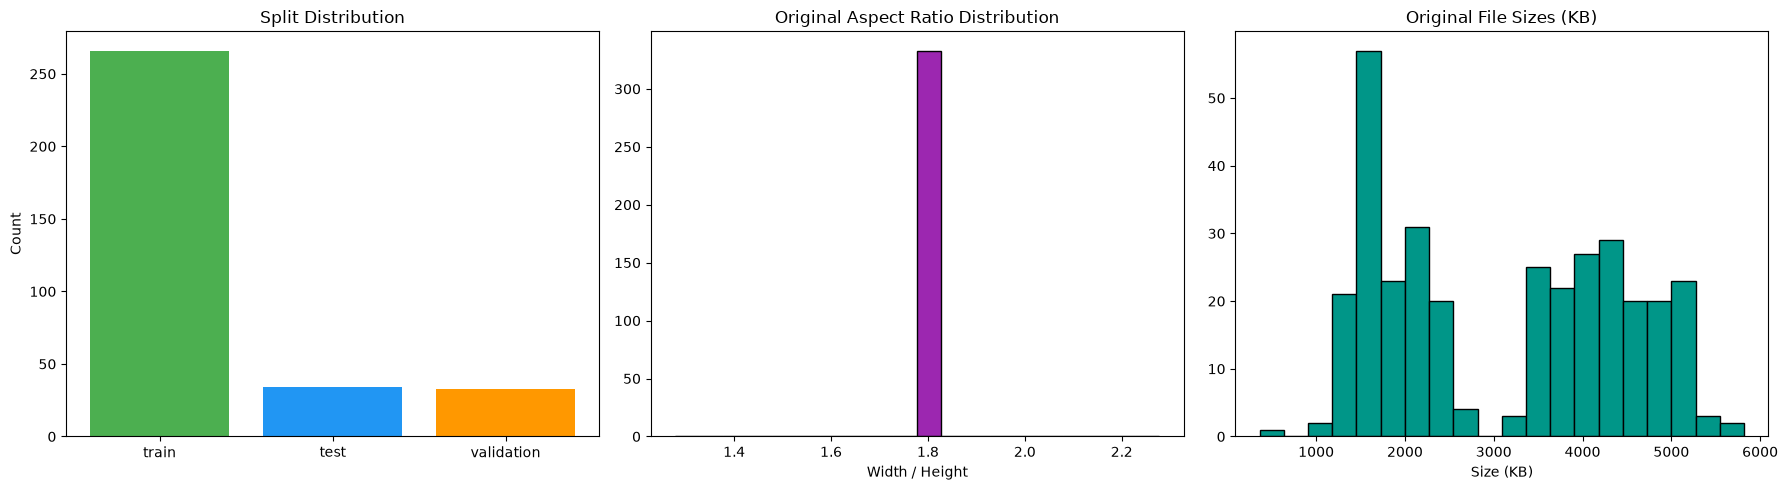

In [12]:
if METADATA_PATH.exists():
    valid_df = df[df["status"] == "valid"].copy()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Splits
    split_counts = valid_df["split"].value_counts()
    axes[0].bar(split_counts.index, split_counts.values, color=["#4CAF50", "#2196F3", "#FF9800"])
    axes[0].set_title("Split Distribution")
    axes[0].set_ylabel("Count")
    
    # 2. Aspect Ratio Distribution
    axes[1].hist(valid_df["aspect_ratio"], bins=20, color="#9C27B0", edgecolor="black")
    axes[1].set_title("Original Aspect Ratio Distribution")
    axes[1].set_xlabel("Width / Height")
    
    # 3. File Sizes
    axes[2].hist(valid_df["file_size_bytes"] / 1024, bins=20, color="#009688", edgecolor="black")
    axes[2].set_title("Original File Sizes (KB)")
    axes[2].set_xlabel("Size (KB)")
    
    plt.tight_layout()
    plt.show()

## 5. Visual Inspection of Processed Samples (Train / Validation / Test)

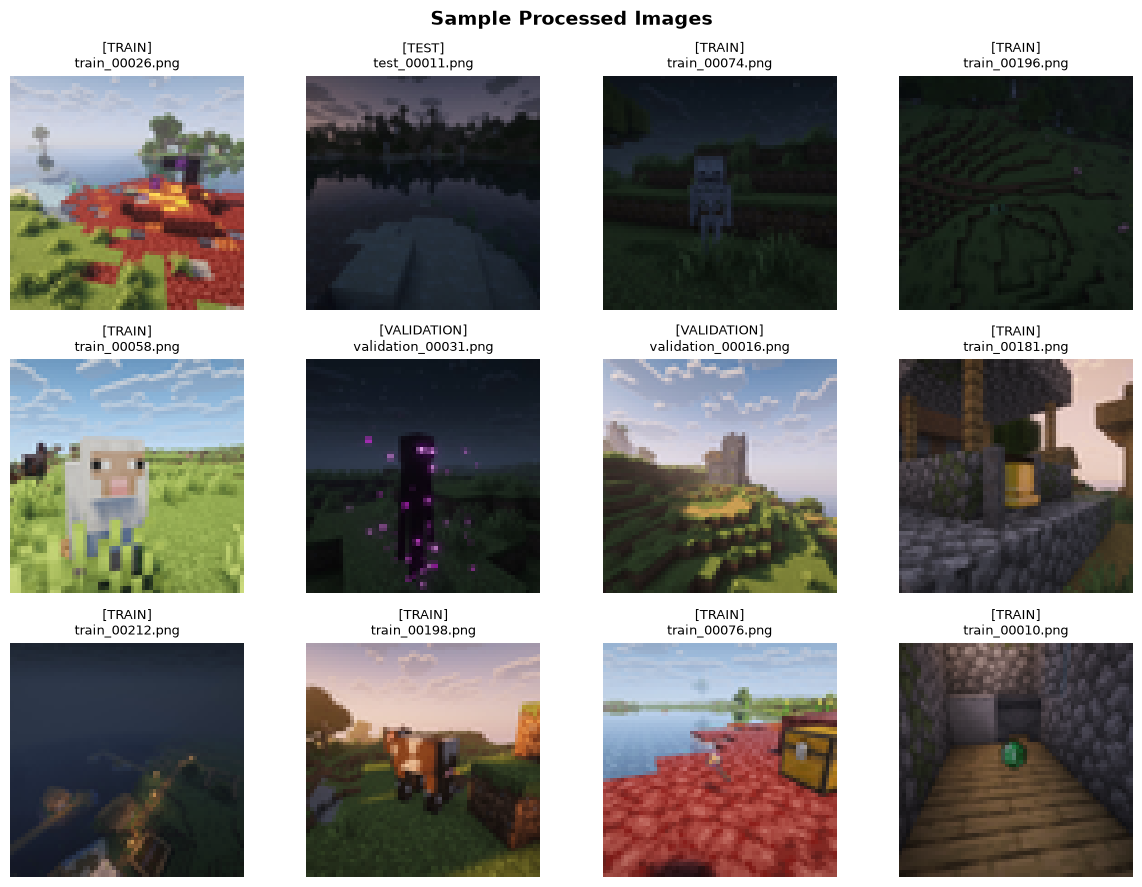

In [13]:
if METADATA_PATH.exists():
    valid_df = df[df["status"] == "valid"]
    sample_df = valid_df.sample(min(12, len(valid_df)), random_state=42) if len(valid_df) > 0 else valid_df
    
    cols = 4
    rows = (len(sample_df) + cols - 1) // cols
    if rows > 0:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
        
        for idx, (_, row) in enumerate(sample_df.iterrows()):
            img_path = Path(row["processed_path"])
            # If running from notebooks/ directory, resolve path relative to repository root
            if not img_path.exists() and (Path("..") / img_path).exists():
                img_path = Path("..") / img_path
            if img_path.exists():
                with Image.open(img_path) as img:
                    axes[idx].imshow(img)
                    axes[idx].set_title(f"[{row['split'].upper()}]\n{row['processed_filename']}", fontsize=9)
                    axes[idx].axis("off")
        
        for idx in range(len(sample_df), len(axes)):
            axes[idx].axis("off")
            
        plt.suptitle("Sample Processed Images", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("No samples available to display.")

## 6. Readiness Verification for ML Training (Phase 2)

Criteria:
- Processed images are non-empty and uniformly sized (e.g. 64x64)
- Formats are 3-channel RGB PNG without alpha anomalies
- Splits are properly balanced across `train`, `validation`, and `test`

In [14]:
if METADATA_PATH.exists():
    valid_df = df[df["status"] == "valid"]
    print(f"Total processed images ready for training: {len(valid_df)}")
    if len(valid_df) > 0:
        first_path = Path(valid_df.iloc[0]["processed_path"])
        if not first_path.exists() and (Path("..") / first_path).exists():
            first_path = Path("..") / first_path
        if first_path.exists():
            with Image.open(first_path) as img:
                print(f"Resolution: {img.size} | Mode: {img.mode} | Format: {img.format}")
        print("\n[PASSED] Dataset pipeline is structured and ready for Phase 2 (DDPM model training)!")
    else:
        print("Add screenshots to data/raw and run prepare_dataset.py to prepare dataset.")

Total processed images ready for training: 333
Resolution: (64, 64) | Mode: RGB | Format: PNG

[PASSED] Dataset pipeline is structured and ready for Phase 2 (DDPM model training)!
